In [43]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import math
from matplotlib.ticker import ScalarFormatter
import flopy
from matplotlib.colors import ListedColormap
import matplotlib.patches as patches
import matplotlib.ticker as mticker
from matplotlib.ticker import FormatStrFormatter
from numpy.ma import count

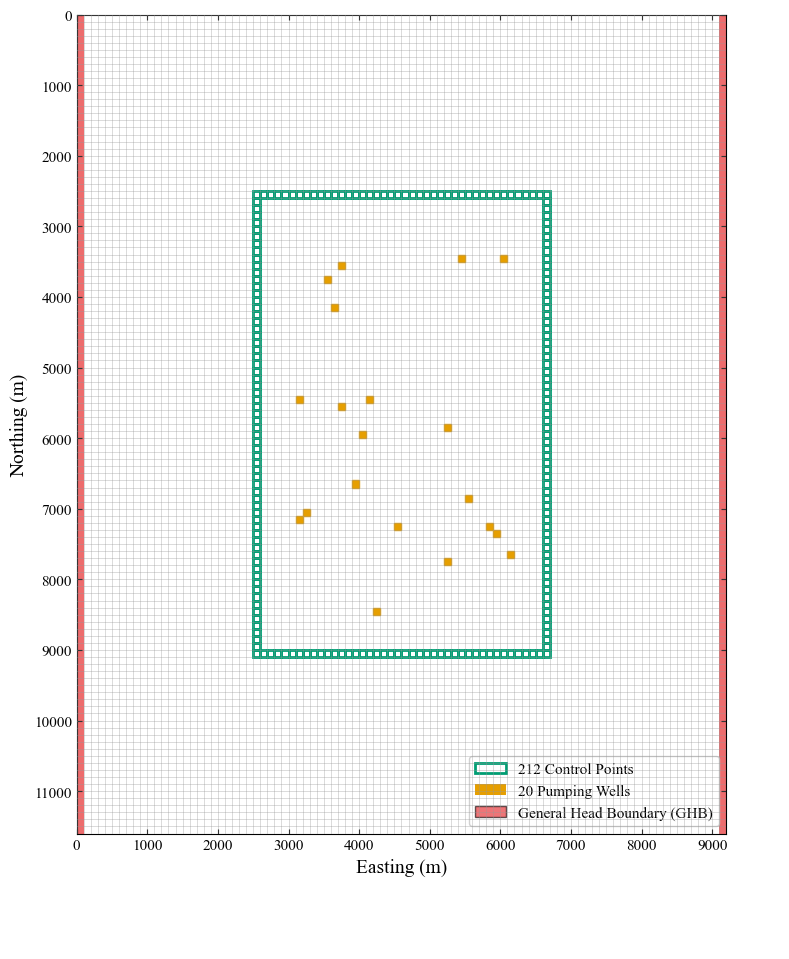

Saved to: C:\Python\Personal\kfm-ms\codes\figures\coloc2_incdd_domain.svg


In [9]:
import os
from pathlib import Path
import flopy
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as patches

# =====================================================================
# 1. PARAMETERS & PATH SPECIFICATIONS
# =====================================================================

ROOT = "coloc2"
notebook_dir = Path(os.getcwd())
codes_root = notebook_dir.parent
sims_dir = codes_root / "sims" / ROOT
real_ws = sims_dir / "real"

sim_real = flopy.mf6.MFSimulation.load(sim_ws=str(real_ws), verbosity_level=0)
gwf = sim_real.get_model("real")
nrow, ncol = gwf.dis.nrow.get_data(), gwf.dis.ncol.get_data()

cell_dim = 100.0
nrow, ncol = int(nrow), int(ncol)
lx_m, ly_m = ncol * cell_dim, nrow * cell_dim

figures_output_path = Path(r"C:\Python\Personal\kfm-ms\codes\figures")
figures_output_path.mkdir(parents=True, exist_ok=True)

# Fixed fonts
size = 14
tick_size = 11

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman", "Liberation Serif", "DejaVu Serif", "Times"]

# =====================================================================
# 2. LOAD WELLS AND COMPLIANCE POINTS
# =====================================================================

siren_coords = []
for folder in [f for f in os.listdir(sims_dir) if f.startswith("siren_")]:
    try:
        p_sim = flopy.mf6.MFSimulation.load(sim_ws=str(sims_dir / folder), verbosity_level=0)
        gwf_p = p_sim.get_model()
        spd_dict = gwf_p.wel.stress_period_data.get_data()

        if 0 in spd_dict and spd_dict[0] is not None:
            for entry in spd_dict[0]:
                r_p = entry["cellid"][1]
                c_p = entry["cellid"][2]
                siren_coords.append((r_p, c_p))
    except Exception as e:
        print(f"Error loading {folder}: {e}")
        continue

sorted_sirens = sorted(list(set(siren_coords)))

margin_size = 25
margin = int(margin_size)
r_start, r_end = margin, (nrow - margin) - 1
c_start, c_end = margin, (ncol - margin) - 1
cp_cells = []

for c in range(c_start, c_end + 1):
    cp_cells.extend([(r_start, c), (r_end, c)])

for r in range(r_start + 1, r_end):
    cp_cells.extend([(r, c_start), (r, c_end)])

sorted_cp = sorted(list(set(cp_cells)))

has_ghb = any(p.package_type == "ghb" for p in gwf.packagelist)

# =====================================================================
# 3. CANVAS PLOT SETUP
# =====================================================================

fig, ax = plt.subplots(1, 1, figsize=(9, 10.5))
fig.subplots_adjust(left=0.12, right=0.96, bottom=0.20, top=0.98)
ax.set_facecolor("white")

mapview = flopy.plot.PlotMapView(model=gwf, ax=ax, layer=0)

if has_ghb:
    mapview.plot_bc(name="GHB", color="#e41a1c", alpha=0.4, zorder=1)

for r, c in sorted_cp:
    rect = patches.Rectangle(
        (c * cell_dim, r * cell_dim),
        cell_dim,
        cell_dim,
        linewidth=2,
        edgecolor="#009E73",
        facecolor="none",
        zorder=3
    )
    ax.add_patch(rect)

for r, c in sorted_sirens:
    rect = patches.Rectangle(
        (c * cell_dim, r * cell_dim),
        cell_dim,
        cell_dim,
        linewidth=1,
        edgecolor="#E69F00",
        facecolor="#E69F00",
        zorder=2
    )
    ax.add_patch(rect)

grid_cfg = {"color": "#999999", "lw": 0.5, "alpha": 0.5, "zorder": 100}
for x in range(ncol + 1):
    ax.plot([x * cell_dim, x * cell_dim], [0, ly_m], **grid_cfg)
for y in range(nrow + 1):
    ax.plot([0, lx_m], [y * cell_dim, y * cell_dim], **grid_cfg)

# =====================================================================
# 4. AXIS SETTINGS
# =====================================================================

ax.set_xlim(0, lx_m)
ax.set_ylim(ly_m, 0)
ax.set_aspect("equal", adjustable="box")

ax.set_xlabel("Easting (m)", fontsize=size)
ax.set_ylabel("Northing (m)", fontsize=size)
ax.tick_params(axis="both", which="major", labelsize=tick_size, direction="in", top=True, right=True)

ax.set_xticks(np.arange(0, lx_m + 1, 1000))
ax.set_yticks(np.arange(0, ly_m + 1, 1000))
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f"))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f"))

# =====================================================================
# 5. LEGEND
# =====================================================================

legend_elements = [
    patches.Patch(facecolor="none", edgecolor="#009E73", linewidth=2, label=f"{len(sorted_cp)} Control Points"),
    patches.Patch(facecolor="#E69F00", edgecolor="none", label=f"{len(sorted_sirens)} Pumping Wells"),
]

if has_ghb:
    legend_elements.append(
        patches.Patch(facecolor="#e41a1c", alpha=0.6, edgecolor="#000000", label="General Head Boundary (GHB)")
    )

ax.legend(
    handles=legend_elements,
    loc="lower right",
    ncol=1,
    facecolor="white",
    edgecolor="#cccccc",
    framealpha=0.9,
    fontsize=tick_size
)

# =====================================================================
# 6. RESERVED BOTTOM SPACE TO MATCH COLORBAR AREA
# =====================================================================

# Invisible spacer axis to reserve the same lower band as the first script's colorbar.
spacer_ax = fig.add_axes([0.12, 0.09, 0.84, 0.06])
spacer_ax.set_axis_off()

# =====================================================================
# 7. EXPORT
# =====================================================================

save_name = figures_output_path / f"{ROOT}_incdd_domain.svg"
plt.savefig(save_name, dpi=300)
plt.show()

print(f"Saved to: {save_name}")

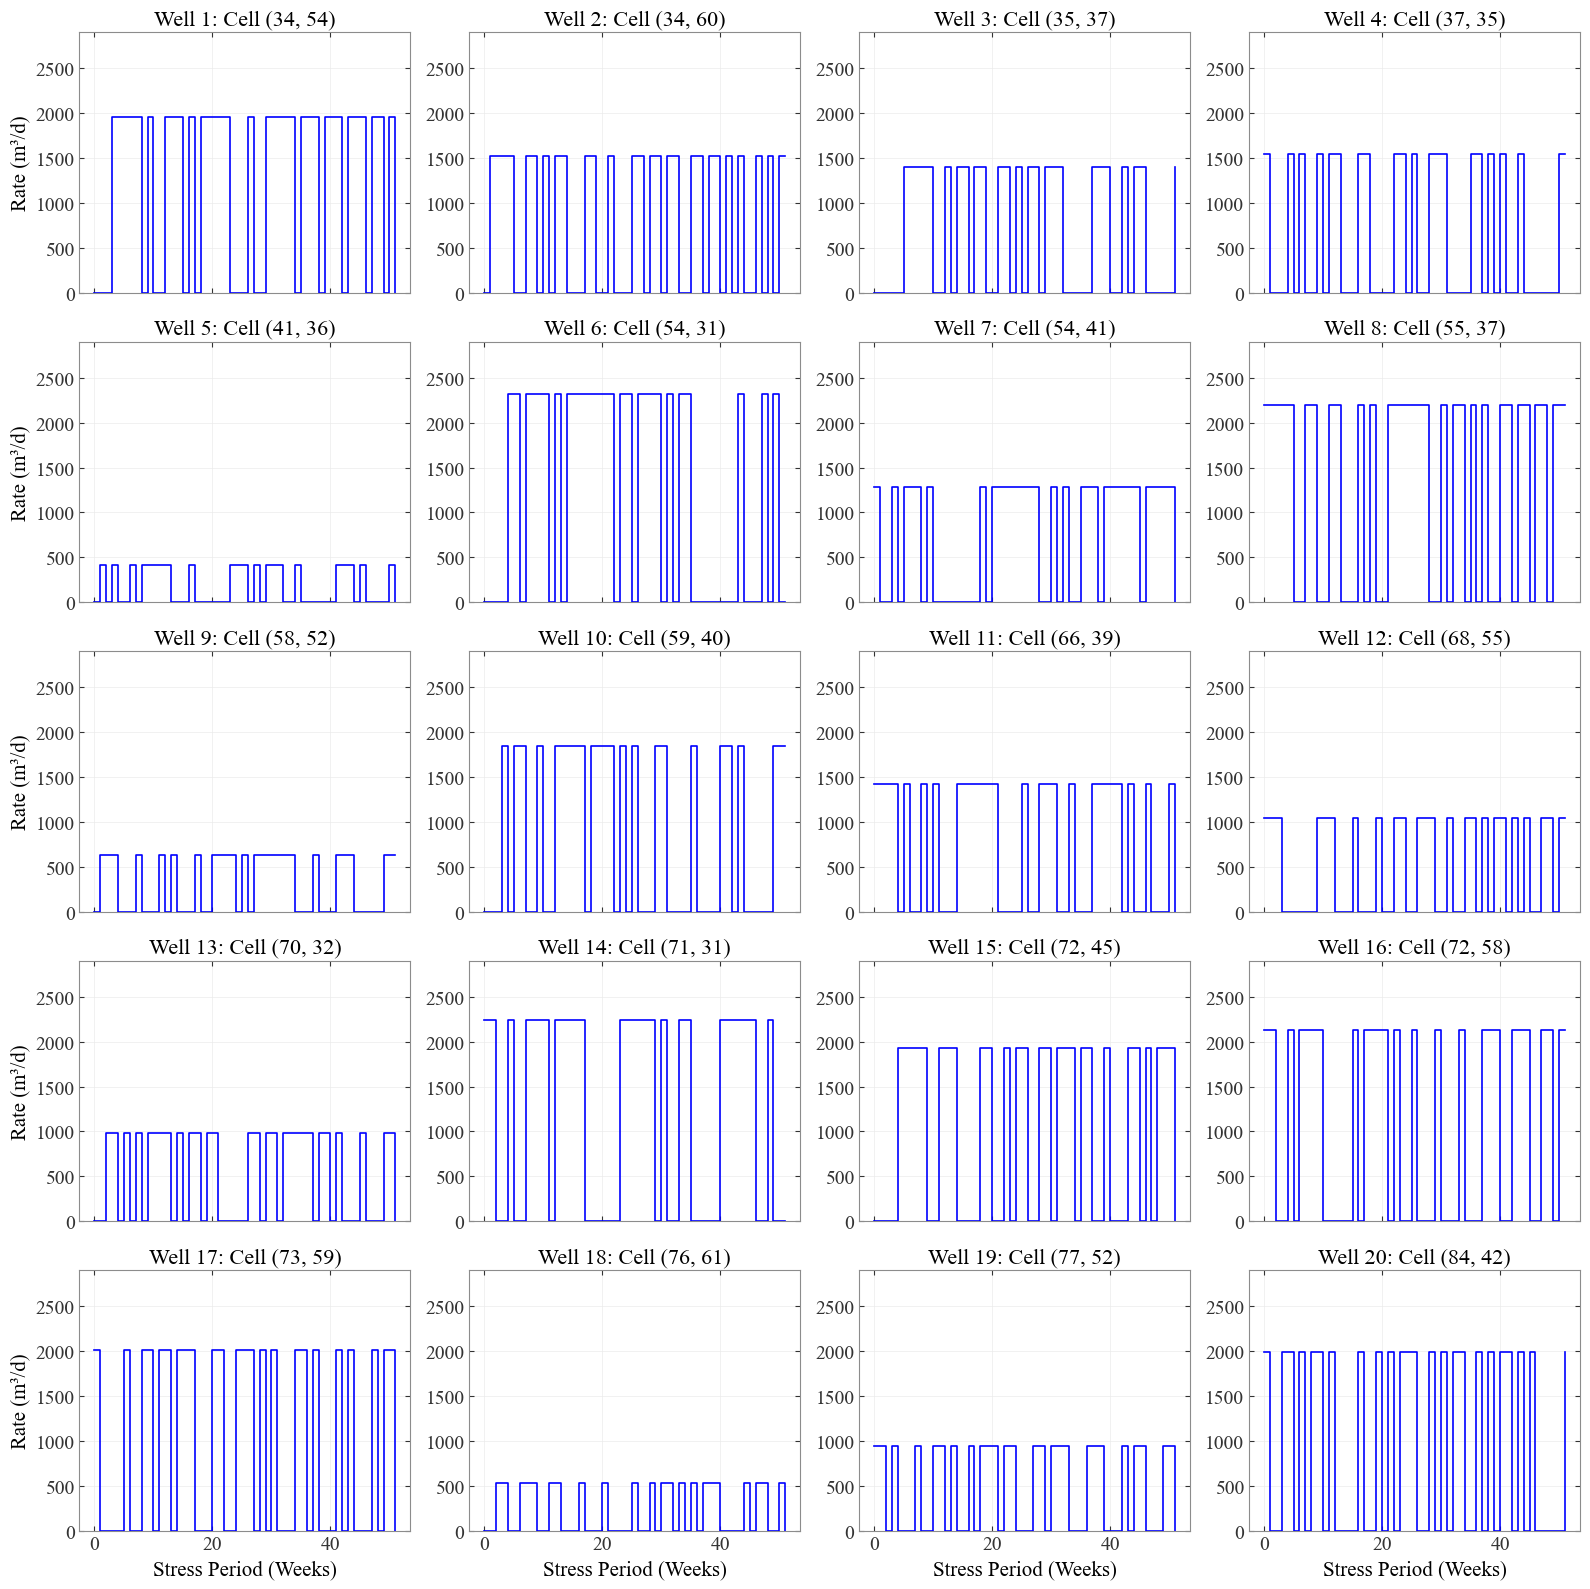

Saved to: C:\Python\Personal\kfm-ms\codes\figures\coloc2_pumping_schedules.svg


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path

# =====================================================================
# 1. CORE PARAMETERS & PATH INITIALIZATION
# =====================================================================
num_root = "coloc2"

# Absolute workspace parameters pointing directly to your active directory branch
sims_data_path = Path(r"C:\Python\Personal\kfm-ms\codes\sims\coloc2")
figures_output_path = Path(r"C:\Python\Personal\kfm-ms\codes\figures")
figures_output_path.mkdir(parents=True, exist_ok=True)

# Standardized font scaling definitions for clean report blocks
size = 18 
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'Liberation Serif', 'DejaVu Serif', 'Times']

truth_file = sims_data_path / "real" / "master_truth.csv"
if not truth_file.exists():
    raise FileNotFoundError(f"Missing schedule dataset at: {truth_file}")

df_q = pd.read_csv(truth_file)

# FIXED: Extract unique well locations strictly using 'r' and 'c' coordinate combinations
unique_wells = df_q[['r', 'c']].drop_duplicates().sort_values(['r', 'c']).reset_index(drop=True)
num_wells = len(unique_wells)

# 4 columns for clean vertical reporting layout
num_cols = 4
num_rows = (num_wells + (num_cols - 1)) // num_cols

# =====================================================================
# 2. GRID ARCHITECTURE INITIALIZATION
# =====================================================================
fig, axes = plt.subplots(num_rows, num_cols, figsize=(16, num_rows * 3.2), sharex=True)
axes = axes.flatten()

# Track maximum rate safely using the explicit 'q' string lookup
global_q_max = df_q['q'].max() if df_q['q'].max() > 0 else 100.0

# =====================================================================
# 3. COORDINATE-BASED STEPPED PROFILE ITERATION
# =====================================================================
for i, (_, row) in enumerate(unique_wells.iterrows()):
    ax = axes[i]
    r, c = int(row['r']), int(row['c'])
    
    ax.set_facecolor('white')
    ax.grid(True, color="#EBEBEB", linestyle="-", linewidth=0.5, zorder=0)
    
    for spine in ax.spines.values():
        spine.set_color('#8c8c8c')
        spine.set_linewidth(0.8)
    
    # FIXED: Filter rows explicitly using 'r' and 'c' keys and sort by stress period 'sp'
    well_mask = (df_q['r'] == r) & (df_q['c'] == c)
    truth_df_sorted = df_q[well_mask].sort_values("sp")
    
    truth_q = truth_df_sorted['q'].values
    stress_periods = truth_df_sorted['sp'].values
    
    # Plot true operational stepped physics curves
    ax.step(stress_periods, truth_q, where='post', color="#0000FF", 
            linewidth=1.2, zorder=10)
    
    # Label panel using sequential index + coordinates to keep names clean
    ax.set_title(f"Well {i + 1}: Cell ({r}, {c})", fontsize=size-2, pad=6)
    ax.set_ylim(0, global_q_max * 1.25)
    
    ax.tick_params(axis='both', which='major', direction='in', labelsize=size-4, colors='#333333', top=True, right=True)
    
    # Label stripping logic for multi-row report grids
    if i % num_cols == 0:
        ax.set_ylabel("Rate (m³/d)", fontsize=size-3, labelpad=4)
    if i >= (num_wells - num_cols):
        ax.set_xlabel("Stress Period (Weeks)", fontsize=size-3, labelpad=4)

# Delete unpopulated hanging axes plots if any remain
for j in range(num_wells, len(axes)):
    fig.delaxes(axes[j])

# =====================================================================
# 4. FILE VECTOR SAVE EXPORT
# =====================================================================
plt.tight_layout()
save_name = figures_output_path / f"{num_root}_pumping_schedules.svg"
plt.savefig(save_name, dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved to: {save_name}")

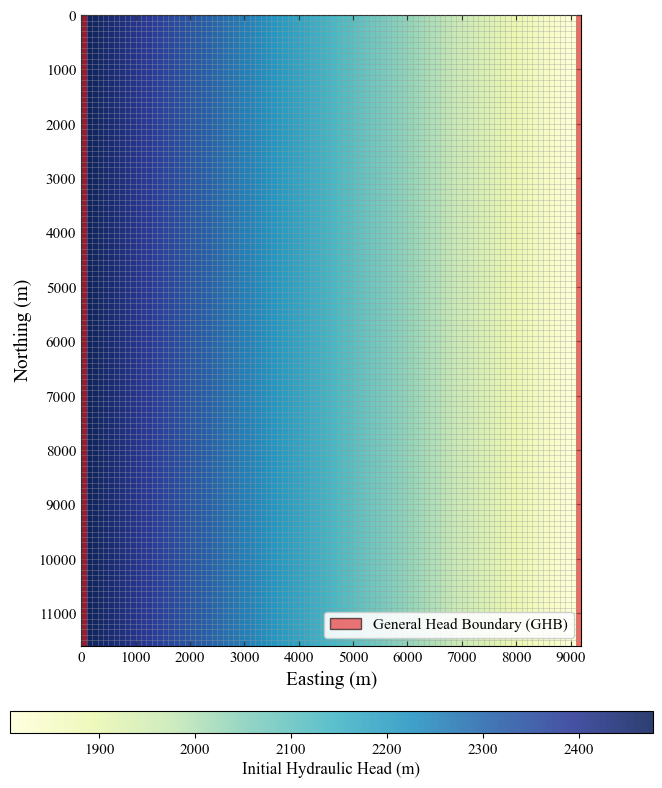

Saved to: C:\Python\Personal\kfm-ms\codes\figures\coloc_domain_icbc_setup.svg


In [8]:
import os
from pathlib import Path
import flopy
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as patches

# =====================================================================
# 1. PARAMETERS & PATH SPECIFICATIONS
# =====================================================================

ROOT = "coloc"
notebook_dir = Path(os.getcwd())
codes_root = notebook_dir.parent
sims_dir = codes_root / "sims" / ROOT
real_ws = sims_dir / "real"

sim_real = flopy.mf6.MFSimulation.load(sim_ws=str(real_ws), verbosity_level=0)
gwf = sim_real.get_model("real")
nrow, ncol = gwf.dis.nrow.get_data(), gwf.dis.ncol.get_data()

cell_dim = 100.0
nrow, ncol = int(nrow), int(ncol)
lx_m, ly_m = ncol * cell_dim, nrow * cell_dim

figures_output_path = Path(r"C:\Python\Personal\kfm-ms\codes\figures")
figures_output_path.mkdir(parents=True, exist_ok=True)

# Fixed fonts
size = 14
tick_size = 11
cbar_size = 12

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman", "Liberation Serif", "DejaVu Serif", "Times"]

# =====================================================================
# 2. CANVAS PLOT SETUP
# =====================================================================

fig, ax = plt.subplots(1, 1, figsize=(9, 10.5))
fig.subplots_adjust(left=0.12, right=0.96, bottom=0.20, top=0.98)
ax.set_facecolor("white")

mapview = flopy.plot.PlotMapView(model=gwf, ax=ax, layer=0)

strt_array = gwf.ic.strt.get_data()[0, :, :]
idomain_array = gwf.dis.idomain.get_data()[0, :, :]

active_heads = strt_array[idomain_array != 0]
dynamic_vmin = active_heads.min()
dynamic_vmax = active_heads.max()

strt_masked = np.ma.masked_where(idomain_array == 0, strt_array)
quadmesh = mapview.plot_array(
    strt_masked,
    cmap="YlGnBu",
    vmin=dynamic_vmin,
    vmax=dynamic_vmax,
    zorder=0,
    alpha=0.85
)

mapview.plot_grid(colors="#999999", linewidths=0.5, zorder=4, alpha=0.5)

legend_elements = []

if np.any(idomain_array == 0):
    mapview.plot_ibound(color_noflow="lightgray", zorder=1)
    legend_elements.append(
        patches.Patch(facecolor="lightgray", edgecolor="#999999", lw=0.5, label="No-Flow Zone")
    )

has_ghb = any(p.package_type == "ghb" for p in gwf.packagelist)
if has_ghb:
    mapview.plot_bc(name="GHB", color="#e41a1c", alpha=0.4, zorder=2)
    legend_elements.append(
        patches.Patch(facecolor="#e41a1c", alpha=0.6, edgecolor="#000000", label="General Head Boundary (GHB)")
    )

# =====================================================================
# 3. AXIS SETTINGS
# =====================================================================

ax.set_xlim(0, lx_m)
ax.set_ylim(ly_m, 0)
ax.set_aspect("equal", adjustable="box")

ax.set_xlabel("Easting (m)", fontsize=size)
ax.set_ylabel("Northing (m)", fontsize=size)
ax.tick_params(axis="both", which="major", labelsize=tick_size, direction="in", top=True, right=True)

ax.set_xticks(np.arange(0, lx_m + 1, 1000))
ax.set_yticks(np.arange(0, ly_m + 1, 1000))
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f"))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f"))

# =====================================================================
# 4. COLORBAR + LEGEND
# =====================================================================

cbar = fig.colorbar(
    quadmesh,
    ax=ax,
    orientation="horizontal",
    shrink=0.85,
    aspect=30,
    pad=0.08
)
cbar.set_label("Initial Hydraulic Head (m)", fontsize=cbar_size, fontweight="medium")
cbar.ax.tick_params(labelsize=tick_size)
cbar.ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f"))

if legend_elements:
    ax.legend(
        handles=legend_elements,
        loc="lower right",
        ncol=1,
        facecolor="white",
        edgecolor="#cccccc",
        framealpha=0.9,
        fontsize=tick_size
    )

# =====================================================================
# 5. EXPORT
# =====================================================================

save_name = figures_output_path / f"{ROOT}_domain_icbc_setup.svg"
plt.savefig(save_name, dpi=300)
plt.show()

print(f"Saved to: {save_name}")

In [4]:
import pandas as pd
import numpy as np
from pathlib import Path

# --- paths ---
results_path = Path("..") / "results"
head_root = "coloc2"

# --- load saved matrices ---
target_heads = pd.read_csv(results_path / f"{head_root}_target_absolute_heads.csv", index_col=0)
surr_heads = pd.read_csv(results_path / f"{head_root}_surrogate_head_match.csv", index_col=0)

# --- reconstruct perimeter cell list exactly as in the generation script ---
nrow, ncol = 116, 92
margin = 25

r_start, r_end = margin, (nrow - margin) - 1
c_start, c_end = margin, (ncol - margin) - 1
cp_cells = []

for c in range(c_start, c_end + 1):
    cp_cells.extend([(r_start, c), (r_end, c)])
for r in range(r_start + 1, r_end):
    cp_cells.extend([(r, c_start), (r, c_end)])

# --- convert to numeric arrays ---
target_vals = target_heads.to_numpy()
surr_vals = surr_heads.to_numpy()

# --- build comparison table ---
rows = []
for sp in range(target_vals.shape[0]):
    for j, (r, c) in enumerate(cp_cells):
        rows.append({
            "stress_period": sp,
            "row": r,
            "col": c,
            "head_pumping_true": target_vals[sp, j],
            "head_pumping_surrogate": surr_vals[sp, j],
        })

master_df = pd.DataFrame(rows)

# --- save ---
output_file = results_path / f"{head_root}_perimeter_head_comparison.csv"
master_df.to_csv(output_file, index=False)

print(f"Saved: {output_file}")

Saved: ..\results\coloc2_perimeter_head_comparison.csv


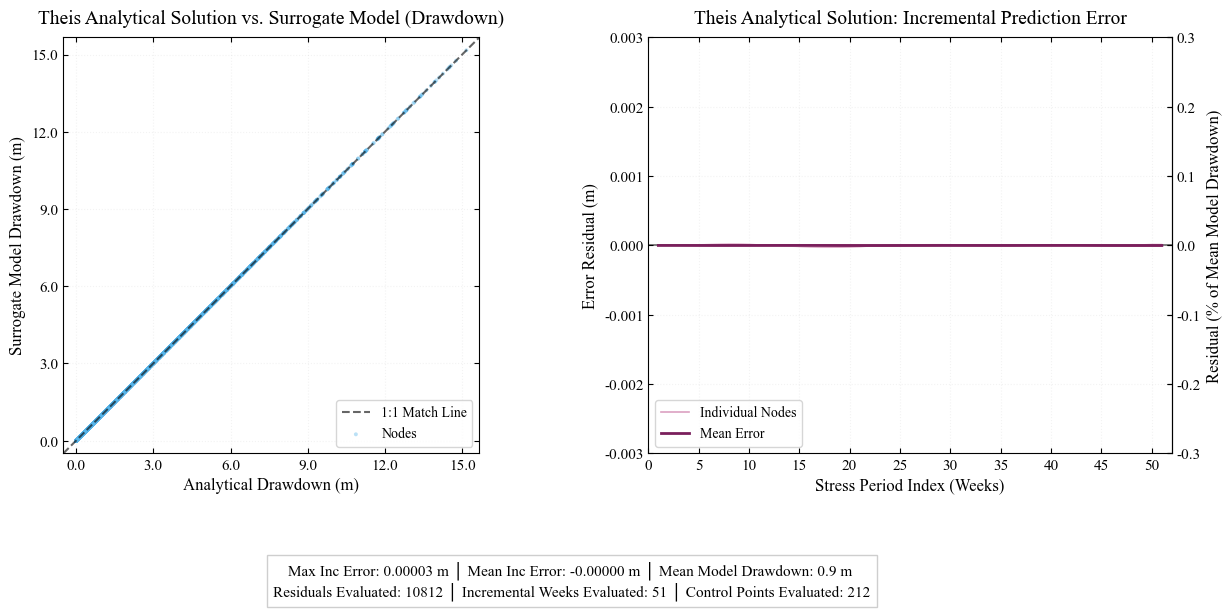

Graphic saved to: C:\Python\Personal\kfm-ms\codes\figures\analytical_inversion_comparison.svg


In [48]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from pathlib import Path

# =====================================================================
# 1. CORE CONFIGURATION & PATH MAPPING
# =====================================================================

num_root = "numbasis"
ana_root = "anabasis"

results_path = Path("..") / "results"
figures_output_path = Path(r"C:\Python\Personal\kfm-ms\codes\figures")
figures_output_path.mkdir(parents=True, exist_ok=True)

# Load Analytical Datasets
num_real = pd.read_csv(results_path / f"{num_root}_target_drawdown.csv", index_col=0)
num_surr = pd.read_csv(results_path / f"{num_root}_surrogate_match.csv", index_col=0)

try:
    ana_real = pd.read_csv(results_path / f"{ana_root}_target_drawdown.csv", index_col=0)
    ana_surr = pd.read_csv(results_path / f"{ana_root}_surrogate_match.csv", index_col=0)
    has_analytical = True
except FileNotFoundError:
    print("Warning: Analytical drawdown data missing. Populating fallback canvas.")
    has_analytical = False

rng = np.random.default_rng(seed=42)

# =====================================================================
# 2. SHARED LAYOUT CONSTANTS
# =====================================================================

size = 14
FIGSIZE = (15, 6.5)
SUBPLOT_ADJUST = dict(wspace=0.22, bottom=0.24, top=0.88)

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman", "Liberation Serif", "DejaVu Serif", "Times"]

fig, axs = plt.subplots(1, 2, figsize=FIGSIZE)
plt.subplots_adjust(**SUBPLOT_ADJUST)

def format_axes(ax):
    ax.tick_params(
        axis='both',
        which='both',
        direction='in',
        top=True,
        right=True,
        labelsize=size - 3,
        colors='black'
    )
    ax.grid(True, alpha=0.15, linestyle=':')

# =====================================================================
# 3. PANEL 1: 1:1 CLOUD MATCH SPACE
# =====================================================================

if has_analytical:
    ana_real_inc = ana_real.diff().dropna()
    ana_surr_inc = ana_surr.diff().dropna()
    ana_err_df = ana_surr_inc - ana_real_inc

    # Keep the first incremental period
    # TAIL CORRECTION: Patch the final Week 52 buffer-shift line derivative anomaly
    ana_err_df.iloc[-1, :] = ana_err_df.iloc[-2, :]
    ana_err_mean = ana_err_df.mean(axis=1)

    ana_flat_real = ana_real.values.flatten()
    ana_flat_surr = ana_surr.values.flatten()
    lims_ana = (
        min(ana_flat_real.min(), ana_flat_surr.min()) - 0.5,
        max(ana_flat_real.max(), ana_flat_surr.max()) + 0.5
    )

    axs[0].set_xlim(lims_ana)
    axs[0].set_ylim(lims_ana)
    axs[0].set_aspect('equal', adjustable='box')
    axs[0].plot(
        lims_ana,
        lims_ana,
        color="black",
        alpha=0.6,
        linestyle='--',
        lw=1.5,
        label='1:1 Match Line'
    )

    ana_x_jitter = ana_flat_real + rng.uniform(-0.001, 0.001, size=ana_flat_real.size)
    ana_y_jitter = ana_flat_surr + rng.uniform(-0.001, 0.001, size=ana_flat_surr.size)

    axs[0].scatter(
        ana_x_jitter,
        ana_y_jitter,
        color='#56B4E9',
        s=8,
        alpha=0.4,
        edgecolors='none',
        label='Nodes'
    )

    axs[0].xaxis.set_major_locator(mticker.MaxNLocator(nbins=6, prune=None))
    axs[0].yaxis.set_major_locator(mticker.MaxNLocator(nbins=6, prune=None))
    axs[0].xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
    axs[0].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

    axs[0].set_title(
        "Theis Analytical Solution vs. Surrogate Model (Drawdown)",
        fontsize=size,
        pad=10,
        fontweight='medium',
        color='black'
    )
    axs[0].set_xlabel("Analytical Drawdown (m)", fontsize=size - 2, color='black')
    axs[0].set_ylabel("Surrogate Model Drawdown (m)", fontsize=size - 2, color='black')
    axs[0].legend(loc='lower right', fontsize=size - 4, framealpha=0.8)

    # =================================================================
    # 4. PANEL 2: INCREMENTAL TIMELINE ERRORS
    # =================================================================

    for i in range(ana_err_df.shape[1]):
        lbl = 'Individual Nodes' if i == 0 else ""
        axs[1].plot(
            ana_err_df.index,
            ana_err_df.values[:, i],
            color='#CC79A7',
            alpha=0.25,
            lw=0.6,
            label=lbl,
            zorder=1
        )

    axs[1].plot(
        ana_err_mean.index,
        ana_err_mean,
        color='#7A1F5C',
        lw=2.0,
        label='Mean Error',
        zorder=2
    )
    axs[1].axhline(0, color='black', lw=1.2, alpha=0.6, zorder=0)

    axs[1].set_ylim(-0.003, 0.003)
    axs[1].set_xlim(0, 52)

    axs[1].xaxis.set_major_locator(mticker.MultipleLocator(5))
    axs[1].yaxis.set_major_locator(mticker.MultipleLocator(0.001))
    axs[1].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))

    axs[1].set_title(
        "Theis Analytical Solution: Incremental Prediction Error",
        fontsize=size,
        pad=10,
        fontweight='medium',
        color='black'
    )
    axs[1].set_xlabel("Stress Period Index (Weeks)", fontsize=size - 2, color='black')
    axs[1].set_ylabel("Error Residual (m)", fontsize=size - 2, color='black')

    # Right axis: same residuals expressed as % of mean model drawdown
    mean_model_drawdown = np.nanmean(ana_real.values)
    if not np.isfinite(mean_model_drawdown) or mean_model_drawdown == 0:
        mean_model_drawdown = 1.0

    def m_to_pct(y):
        return 100.0 * y / mean_model_drawdown

    def pct_to_m(y):
        return y * mean_model_drawdown / 100.0

    ax2 = axs[1].secondary_yaxis('right', functions=(m_to_pct, pct_to_m))
    ax2.set_ylabel("Residual (% of Mean Model Drawdown)", fontsize=size - 2, color='black')
    ax2.tick_params(axis='y', labelcolor='black', labelsize=size - 3, direction='in', colors='black')
    ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

    left_ticks = axs[1].get_yticks()
    ax2.set_yticks(m_to_pct(left_ticks))

    node_handle = Line2D([0], [0], color='#CC79A7', lw=1.2, alpha=0.7, label='Individual Nodes')
    mean_handle = Line2D([0], [0], color='#7A1F5C', lw=2.0, label='Mean Error')
    axs[1].legend(handles=[node_handle, mean_handle], loc='lower left', fontsize=size - 4, framealpha=0.8)

    for ax in axs:
        format_axes(ax)

    ax2.tick_params(axis='y', which='both', direction='in', colors='black')

# =====================================================================
# 5. SLIDE FOOTER GENERATION
# =====================================================================

if has_analytical:
    stats_text = (
        f"Max Inc Error: {ana_err_df.abs().max().max():.5f} m │ Mean Inc Error: {ana_err_mean.mean():.5f} m │ "
        f"Mean Model Drawdown: {mean_model_drawdown:.1f} m \n"
        f"Residuals Evaluated: {ana_err_df.size} │ "
        f"Incremental Weeks Evaluated: {ana_err_df.shape[0]} │ Control Points Evaluated: {ana_err_df.shape[1]}"
    )
else:
    stats_text = "Theis Analytical Matrix Datasets Missing or Unavailable."

fig.text(
    0.5,
    0.02,
    stats_text,
    ha='center',
    fontsize=size - 3,
    fontweight='medium',
    bbox=dict(facecolor='white', alpha=0.95, edgecolor='#cccccc', boxstyle='square,pad=0.4')
)

# =====================================================================
# 6. SAVE / SHOW
# =====================================================================

save_name = figures_output_path / "analytical_inversion_comparison.svg"
plt.savefig(save_name, dpi=300, bbox_inches='tight')
plt.show()

if has_analytical:
    print(f"Graphic saved to: {save_name}")

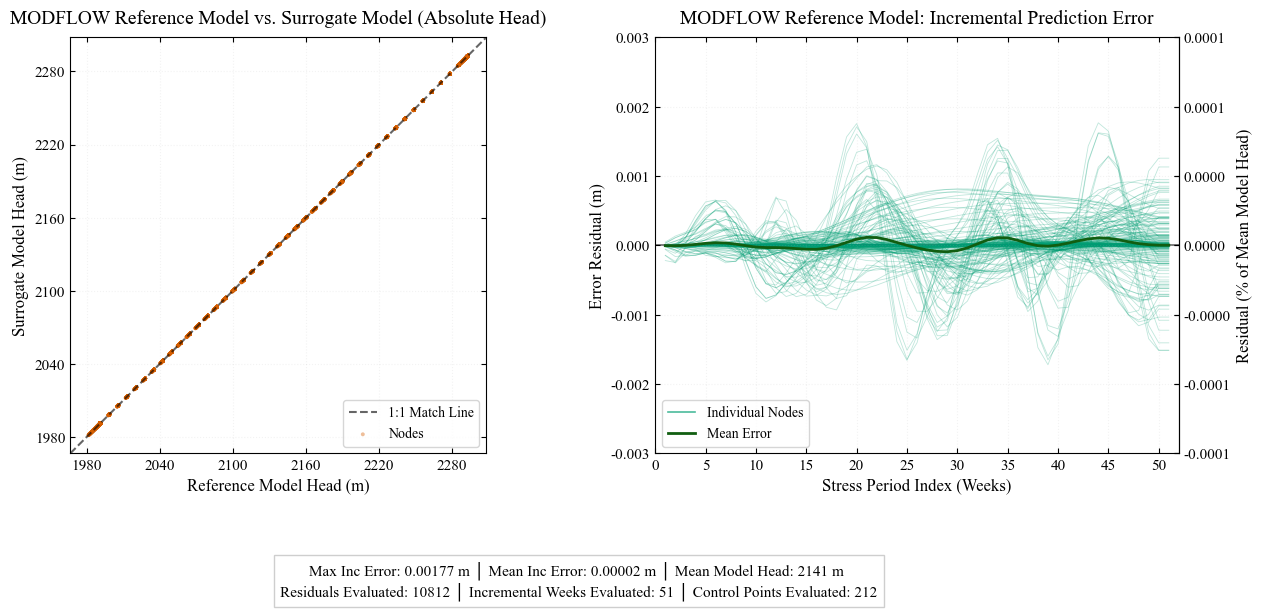

Graphic saved to: C:\Python\Personal\kfm-ms\codes\figures\numerical_inversion_comparison.svg


In [46]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from pathlib import Path

# =====================================================================
# 1. CORE CONFIGURATION & PATH MAPPING
# =====================================================================

head_root = "coloc2"

results_path = Path("..") / "results"
figures_output_path = Path(r"C:\Python\Personal\kfm-ms\codes\figures")
figures_output_path.mkdir(parents=True, exist_ok=True)

comparison_file = results_path / f"{head_root}_perimeter_head_comparison.csv"
if not comparison_file.exists():
    raise FileNotFoundError(
        f"Missing validation file at: {comparison_file}. Ensure extraction tasks executed."
    )

master_df = pd.read_csv(comparison_file)

# Pivot entries back to explicit multidimensional layout arrays
head_true = master_df.pivot_table(
    index="stress_period",
    columns=["row", "col"],
    values="head_pumping_true",
    aggfunc="mean"
)
head_surr = master_df.pivot_table(
    index="stress_period",
    columns=["row", "col"],
    values="head_pumping_surrogate",
    aggfunc="mean"
)

rng = np.random.default_rng(seed=42)

# =====================================================================
# 2. SHARED LAYOUT CONSTANTS
# =====================================================================

size = 14
FIGSIZE = (15, 6.5)
SUBPLOT_ADJUST = dict(wspace=0.22, bottom=0.24, top=0.88)

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman", "Liberation Serif", "DejaVu Serif", "Times"]

fig, axs = plt.subplots(1, 2, figsize=FIGSIZE)
plt.subplots_adjust(**SUBPLOT_ADJUST)

def format_axes(ax):
    ax.tick_params(
        axis='both',
        which='both',
        direction='in',
        top=True,
        right=True,
        labelsize=size - 3,
        colors='black'
    )
    ax.grid(True, alpha=0.15, linestyle=':')

# Regional view bound setup
min_h_data = float(head_true.values.min()) - 15.0
max_h_data = float(head_true.values.max()) + 15.0
axis_bounds_head = (min_h_data, max_h_data)

# =====================================================================
# PANEL 1: 1:1 ABSOLUTE HEAD CLOUD SPACE
# =====================================================================

axs[0].set_xlim(axis_bounds_head)
axs[0].set_ylim(axis_bounds_head)
axs[0].set_aspect('equal', adjustable='box')
axs[0].plot(
    axis_bounds_head,
    axis_bounds_head,
    color="black",
    alpha=0.6,
    linestyle='--',
    lw=1.5,
    label='1:1 Match Line'
)

head_x_jitter = head_true.values.flatten() + rng.uniform(-0.01, 0.01, size=head_true.size)
head_y_jitter = head_surr.values.flatten() + rng.uniform(-0.01, 0.01, size=head_surr.size)

axs[0].scatter(
    head_x_jitter,
    head_y_jitter,
    color='#d55e00',
    s=8,
    alpha=0.4,
    edgecolors='none',
    label='Nodes'
)

axs[0].xaxis.set_major_locator(mticker.MaxNLocator(nbins=6, prune=None))
axs[0].yaxis.set_major_locator(mticker.MaxNLocator(nbins=6, prune=None))
axs[0].xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
axs[0].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))

axs[0].set_title(
    "MODFLOW Reference Model vs. Surrogate Model (Absolute Head)",
    fontsize=size,
    pad=10,
    fontweight='medium',
    color='black'
)
axs[0].set_xlabel("Reference Model Head (m)", fontsize=size - 2, color='black')
axs[0].set_ylabel("Surrogate Model Head (m)", fontsize=size - 2, color='black')
axs[0].legend(loc='lower right', fontsize=size - 4, framealpha=0.8)

# =====================================================================
# PANEL 2: INCREMENTAL TIMELINE ERRORS
# =====================================================================

head_true_inc = head_true.diff().dropna()
head_surr_inc = head_surr.diff().fillna(0).loc[head_true_inc.index]
head_err_df = head_surr_inc - head_true_inc

# Keep the first incremental period
# TAIL CORRECTION: Patch the final Week 52 buffer-shift line derivative anomaly
head_err_df.iloc[-1, :] = head_err_df.iloc[-2, :]
head_err_mean = head_err_df.mean(axis=1)

# Right axis relative to mean model head
mean_model_head = np.nanmean(head_true.values)
if not np.isfinite(mean_model_head) or mean_model_head == 0:
    mean_model_head = 1.0

# Left axis: absolute residuals in meters
for i in range(head_err_df.shape[1]):
    lbl = 'Individual Nodes' if i == 0 else ""
    axs[1].plot(
        head_err_df.index,
        head_err_df.values[:, i],
        color='#009E73',
        alpha=0.25,
        lw=0.6,
        label=lbl,
        zorder=1
    )

axs[1].plot(
    head_err_mean.index,
    head_err_mean,
    color='#115e11',
    lw=2.0,
    label='Mean Error',
    zorder=2
)
axs[1].axhline(0, color='black', lw=1.2, alpha=0.6, zorder=0)

axs[1].set_ylim(-0.003, 0.003)
axs[1].set_xlim(0, 52)

axs[1].xaxis.set_major_locator(mticker.MultipleLocator(5))
axs[1].yaxis.set_major_locator(mticker.MultipleLocator(0.001))
axs[1].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))

axs[1].set_title(
    "MODFLOW Reference Model: Incremental Prediction Error",
    fontsize=size,
    pad=10,
    fontweight='medium',
    color='black'
)
axs[1].set_xlabel("Stress Period Index (Weeks)", fontsize=size - 2, color='black')
axs[1].set_ylabel("Error Residual (m)", fontsize=size - 2, color='black')

# Better legend handles so the individual nodes are visible in the legend
node_handle = Line2D([0], [0], color='#009E73', lw=1.2, alpha=0.7, label='Individual Nodes')
mean_handle = Line2D([0], [0], color='#115e11', lw=2.0, label='Mean Error')
axs[1].legend(handles=[node_handle, mean_handle], loc='lower left', fontsize=size - 4, framealpha=0.8)

# Secondary right axis: same curves expressed as % of mean model head
def m_to_pct(y):
    return 100.0 * y / mean_model_head

def pct_to_m(y):
    return y * mean_model_head / 100.0

ax2 = axs[1].secondary_yaxis('right', functions=(m_to_pct, pct_to_m))
ax2.set_ylabel("Residual (% of Mean Model Head)", fontsize=size - 2, color='black')
ax2.tick_params(axis='y', labelcolor='black', labelsize=size - 3, direction='in', colors='black')
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.4f'))

left_ticks = axs[1].get_yticks()
ax2.set_yticks(m_to_pct(left_ticks))

# =====================================================================
# 3. FORMATTING
# =====================================================================

for ax in axs:
    format_axes(ax)

ax2.tick_params(axis='y', which='both', direction='in', colors='black')

# =====================================================================
# 4. SLIDE FOOTER GENERATION
# =====================================================================

stats_text = (
    f"Max Inc Error: {head_err_df.abs().max().max():.5f} m │ Mean Inc Error: {head_err_mean.mean():.5f} m │ "
    f"Mean Model Head: {mean_model_head:.0f} m \n"
    f"Residuals Evaluated: {head_err_df.size} │ "
    f"Incremental Weeks Evaluated: {head_err_df.shape[0]} │ Control Points Evaluated: {head_err_df.shape[1]}"
)

fig.text(
    0.5,
    0.02,
    stats_text,
    ha='center',
    fontsize=size - 3,
    fontweight='medium',
    bbox=dict(facecolor='white', alpha=0.95, edgecolor='#cccccc', boxstyle='square,pad=0.4')
)

# =====================================================================
# 5. SAVE / SHOW
# =====================================================================

save_name = figures_output_path / "numerical_inversion_comparison.svg"
plt.savefig(save_name, dpi=300, bbox_inches='tight')
plt.show()

print(f"Graphic saved to: {save_name}")

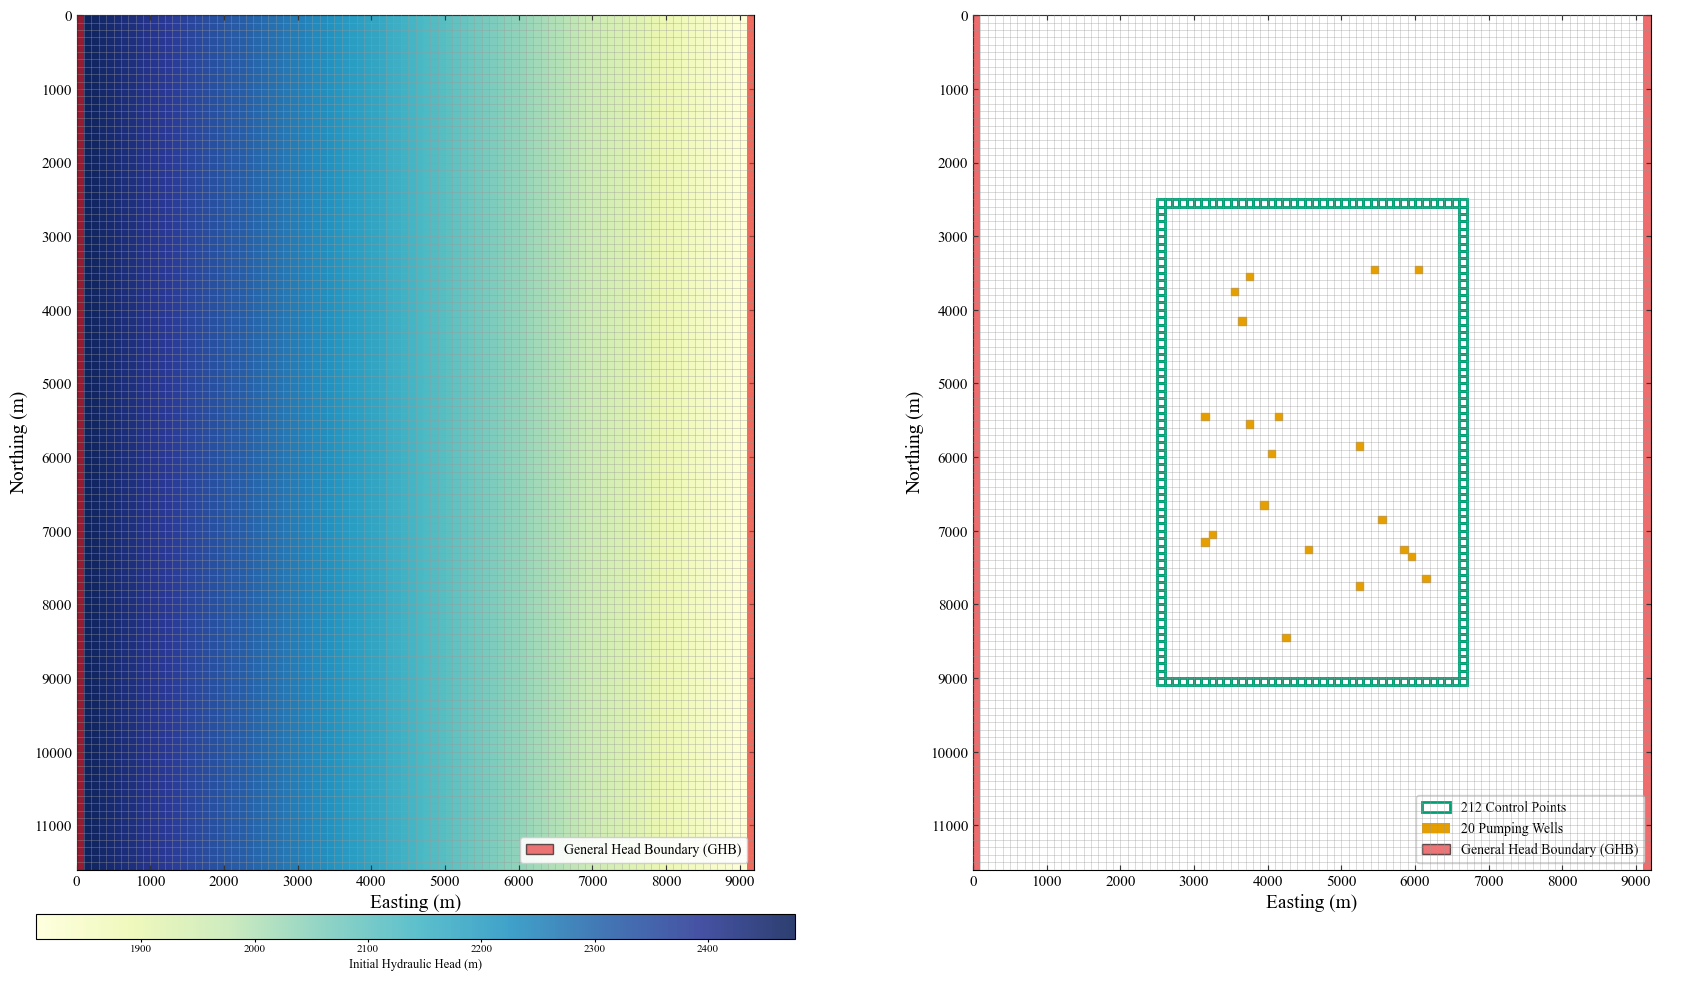

Saved to: C:\Python\Personal\kfm-ms\codes\figures\coloc_coloc2_side_by_side.svg


In [14]:
import os
from pathlib import Path
import flopy
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as patches
from matplotlib.gridspec import GridSpec

# =====================================================================
# 1. PARAMETERS & PATH SPECIFICATIONS
# =====================================================================

ROOT_LEFT = "coloc"
ROOT_RIGHT = "coloc2"

notebook_dir = Path(os.getcwd())
codes_root = notebook_dir.parent

sims_dir_left = codes_root / "sims" / ROOT_LEFT
sims_dir_right = codes_root / "sims" / ROOT_RIGHT

real_ws_left = sims_dir_left / "real"
real_ws_right = sims_dir_right / "real"

figures_output_path = Path(r"C:\Python\Personal\kfm-ms\codes\figures")
figures_output_path.mkdir(parents=True, exist_ok=True)

# Load simulations
sim_left = flopy.mf6.MFSimulation.load(sim_ws=str(real_ws_left), verbosity_level=0)
gwf_left = sim_left.get_model("real")
nrow_left, ncol_left = gwf_left.dis.nrow.get_data(), gwf_left.dis.ncol.get_data()

sim_right = flopy.mf6.MFSimulation.load(sim_ws=str(real_ws_right), verbosity_level=0)
gwf_right = sim_right.get_model("real")
nrow_right, ncol_right = gwf_right.dis.nrow.get_data(), gwf_right.dis.ncol.get_data()

# Structural grid dimension parameters
cell_dim = 100.0
nrow_left, ncol_left = int(nrow_left), int(ncol_left)
nrow_right, ncol_right = int(nrow_right), int(ncol_right)

lx_left, ly_left = ncol_left * cell_dim, nrow_left * cell_dim
lx_right, ly_right = ncol_right * cell_dim, nrow_right * cell_dim

# Styling
size = 14
tick_size = 11
cbar_size = 9

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman", "Liberation Serif", "DejaVu Serif", "Times"]

# =====================================================================
# 2. LOAD WELLS AND CONTROL POINTS FOR RIGHT PANEL
# =====================================================================

siren_coords = []
for folder in [f for f in os.listdir(sims_dir_right) if f.startswith("siren_")]:
    try:
        p_sim = flopy.mf6.MFSimulation.load(sim_ws=str(sims_dir_right / folder), verbosity_level=0)
        gwf_p = p_sim.get_model()
        spd_dict = gwf_p.wel.stress_period_data.get_data()

        if 0 in spd_dict and spd_dict[0] is not None:
            for entry in spd_dict[0]:
                siren_coords.append((entry["cellid"][1], entry["cellid"][2]))
    except Exception as e:
        print(f"Error loading {folder}: {e}")
        continue

sorted_sirens = sorted(set(siren_coords))

margin_size = 25
margin = int(margin_size)
r_start, r_end = margin, (nrow_right - margin) - 1
c_start, c_end = margin, (ncol_right - margin) - 1
cp_cells = []

for c in range(c_start, c_end + 1):
    cp_cells.extend([(r_start, c), (r_end, c)])

for r in range(r_start + 1, r_end):
    cp_cells.extend([(r, c_start), (r, c_end)])

sorted_cp = sorted(set(cp_cells))

has_ghb_left = any(p.package_type == "ghb" for p in gwf_left.packagelist)
has_ghb_right = any(p.package_type == "ghb" for p in gwf_right.packagelist)

# =====================================================================
# 3. FIGURE LAYOUT
# =====================================================================

fig = plt.figure(figsize=(18, 10.5))
gs = GridSpec(
    2, 2,
    height_ratios=[20, 0.6],   # thin but readable colorbar row
    width_ratios=[1, 1],
    figure=fig
)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
cax1 = fig.add_subplot(gs[1, 0])
cax2 = fig.add_subplot(gs[1, 1])

fig.subplots_adjust(left=0.06, right=0.98, bottom=0.08, top=0.96, wspace=0.18, hspace=0.10)

# =====================================================================
# 4. LEFT PANEL
# =====================================================================

ax1.set_facecolor("white")
mapview1 = flopy.plot.PlotMapView(model=gwf_left, ax=ax1, layer=0)

strt_array = gwf_left.ic.strt.get_data()[0, :, :]
idomain_array = gwf_left.dis.idomain.get_data()[0, :, :]

active_heads = strt_array[idomain_array != 0]
dynamic_vmin = active_heads.min()
dynamic_vmax = active_heads.max()

strt_masked = np.ma.masked_where(idomain_array == 0, strt_array)
quadmesh = mapview1.plot_array(
    strt_masked,
    cmap="YlGnBu",
    vmin=dynamic_vmin,
    vmax=dynamic_vmax,
    zorder=0,
    alpha=0.85
)

mapview1.plot_grid(colors="#999999", linewidths=0.5, zorder=4, alpha=0.5)

legend_elements_left = []
if np.any(idomain_array == 0):
    mapview1.plot_ibound(color_noflow="lightgray", zorder=1)
    legend_elements_left.append(
        patches.Patch(facecolor="lightgray", edgecolor="#999999", lw=0.5, label="No-Flow Zone")
    )

if has_ghb_left:
    mapview1.plot_bc(name="GHB", color="#e41a1c", alpha=0.4, zorder=2)
    legend_elements_left.append(
        patches.Patch(facecolor="#e41a1c", alpha=0.6, edgecolor="#000000", label="General Head Boundary (GHB)")
    )

ax1.set_xlim(0, lx_left)
ax1.set_ylim(ly_left, 0)
ax1.set_aspect("equal", adjustable="box")
ax1.set_xlabel("Easting (m)", fontsize=size)
ax1.set_ylabel("Northing (m)", fontsize=size)
ax1.tick_params(axis="both", which="major", labelsize=tick_size, direction="in", top=True, right=True)
ax1.set_xticks(np.arange(0, lx_left + 1, 1000))
ax1.set_yticks(np.arange(0, ly_left + 1, 1000))
ax1.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f"))
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f"))

# Thin colorbar, with a little more padding below the axis
cbar = fig.colorbar(quadmesh, cax=cax1, orientation="horizontal")
cbar.set_label("Initial Hydraulic Head (m)", fontsize=cbar_size, labelpad=4)
cbar.ax.tick_params(labelsize=8, length=2, pad=1)
cbar.ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f"))

# Keep the right bottom slot empty to preserve alignment
cax2.set_axis_off()

if legend_elements_left:
    ax1.legend(
        handles=legend_elements_left,
        loc="lower right",
        ncol=1,
        facecolor="white",
        edgecolor="#cccccc",
        framealpha=0.9,
        fontsize=tick_size - 1
    )

# =====================================================================
# 5. RIGHT PANEL
# =====================================================================

ax2.set_facecolor("white")
mapview2 = flopy.plot.PlotMapView(model=gwf_right, ax=ax2, layer=0)

if has_ghb_right:
    mapview2.plot_bc(name="GHB", color="#e41a1c", alpha=0.4, zorder=1)

for r, c in sorted_cp:
    rect = patches.Rectangle(
        (c * cell_dim, r * cell_dim),
        cell_dim,
        cell_dim,
        linewidth=2,
        edgecolor="#009E73",
        facecolor="none",
        zorder=3
    )
    ax2.add_patch(rect)

for r, c in sorted_sirens:
    rect = patches.Rectangle(
        (c * cell_dim, r * cell_dim),
        cell_dim,
        cell_dim,
        linewidth=1,
        edgecolor="#E69F00",
        facecolor="#E69F00",
        zorder=2
    )
    ax2.add_patch(rect)

grid_cfg = {"color": "#999999", "lw": 0.5, "alpha": 0.5, "zorder": 100}
for x in range(ncol_right + 1):
    ax2.plot([x * cell_dim, x * cell_dim], [0, ly_right], **grid_cfg)
for y in range(nrow_right + 1):
    ax2.plot([0, lx_right], [y * cell_dim, y * cell_dim], **grid_cfg)

ax2.set_xlim(0, lx_right)
ax2.set_ylim(ly_right, 0)
ax2.set_aspect("equal", adjustable="box")
ax2.set_xlabel("Easting (m)", fontsize=size)
ax2.set_ylabel("Northing (m)", fontsize=size)
ax2.tick_params(axis="both", which="major", labelsize=tick_size, direction="in", top=True, right=True)
ax2.set_xticks(np.arange(0, lx_right + 1, 1000))
ax2.set_yticks(np.arange(0, ly_right + 1, 1000))
ax2.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f"))
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f"))

legend_elements_right = [
    patches.Patch(facecolor="none", edgecolor="#009E73", linewidth=2, label=f"{len(sorted_cp)} Control Points"),
    patches.Patch(facecolor="#E69F00", edgecolor="none", label=f"{len(sorted_sirens)} Pumping Wells"),
]

if has_ghb_right:
    legend_elements_right.append(
        patches.Patch(facecolor="#e41a1c", alpha=0.6, edgecolor="#000000", label="General Head Boundary (GHB)")
    )

ax2.legend(
    handles=legend_elements_right,
    loc="lower right",
    ncol=1,
    facecolor="white",
    edgecolor="#cccccc",
    framealpha=0.9,
    fontsize=tick_size - 1
)

# =====================================================================
# 6. EXPORT
# =====================================================================

save_name = figures_output_path / "coloc_coloc2_side_by_side.svg"
plt.savefig(save_name, dpi=300)
plt.show()

print(f"Saved to: {save_name}")